# Quant Factor Ranking — Research Notebook

A cross-sectional, machine-learning **ranking** model for the S&P 500. This single notebook is
the running narrative of the whole project; each stage carries its own **data collection** and
**data validation** before analysis. Heavy computation lives in the `qfr` package (`src/qfr/`);
here we load and display the results so the notebook stays fast and readable.

**Contents**
1. Data Collection & the Point-in-Time Dataset
1b. Independent Data Validation (FMP vs Yahoo Finance)
2. Exploratory Data Analysis

*(Parts 3–8 — factors, validation, models, portfolio — will be appended as the project grows.)*

In [1]:
import pandas as pd
from IPython.display import Image
from qfr.utils.config import settings, PROJECT_ROOT

P = settings.processed_dir
CHARTS = PROJECT_ROOT / 'charts'
raw = pd.read_parquet(P / 'master_pit.parquet')        # pre-validation panel
clean = pd.read_parquet(P / 'master_clean.parquet')    # canonical panel (post-validation)
universe = pd.read_parquet(P / 'universe_panel.parquet')
members_now = pd.read_parquet(P / 'members_now.parquet')
print('panels loaded:', raw.shape, '(raw)', clean.shape, '(clean)')

panels loaded: (158243, 61) (raw) (158243, 63) (clean)


# 1. Data Collection & the Point-in-Time Dataset

**Goal:** a dataset free of the two biases that quietly inflate most backtests — *survivorship*
(only studying today's index) and *look-ahead* (using a fundamental before it was public).
Source: Financial Modeling Prep (stable API). Universe: point-in-time S&P 500, monthly, 2000–2026.

## 1.1 Universe — point-in-time & survivorship-bias-free
We reconstruct membership as-of each date from FMP's change-log (walked backwards). **1,088**
distinct names pass through the index over the sample vs ~500 today.

current members       : 503
ever in-universe       : 1088
member-months (2000+)  : 158,243


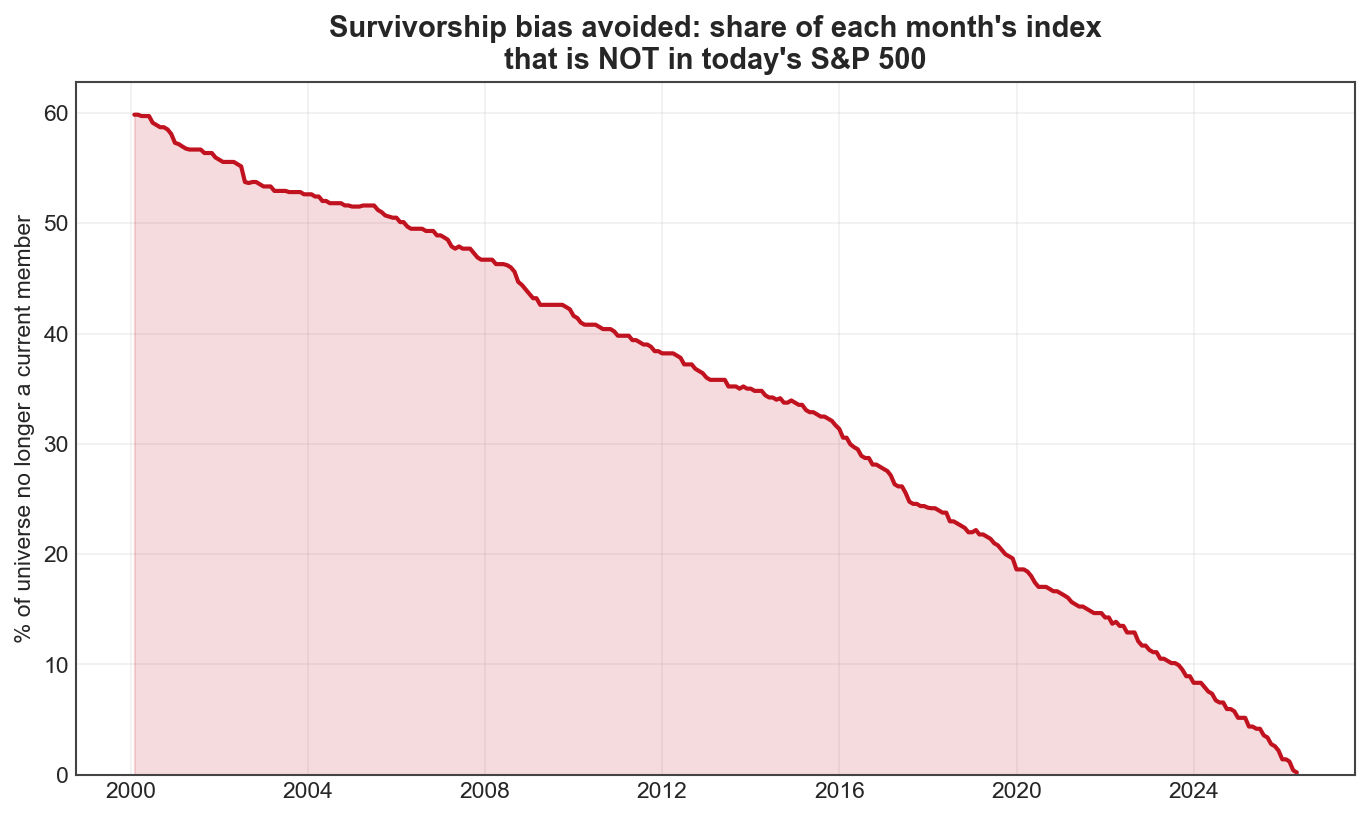

In [2]:
print(f'current members       : {len(members_now)}')
print(f'ever in-universe       : {universe.symbol.nunique()}')
print(f'member-months (2000+)  : {len(raw):,}')
Image(filename=str(CHARTS / '01_survivorship_bias.png'))

## 1.2 No look-ahead — fundamentals lagged to filing date
A fundamental is usable only once its SEC filing was *accepted* (`acceptedDate`). The check below
confirms zero violations across every investable observation.

investable member-months : 130,737
look-ahead violations    : 0
filing lag (days): median 49 | p95 93


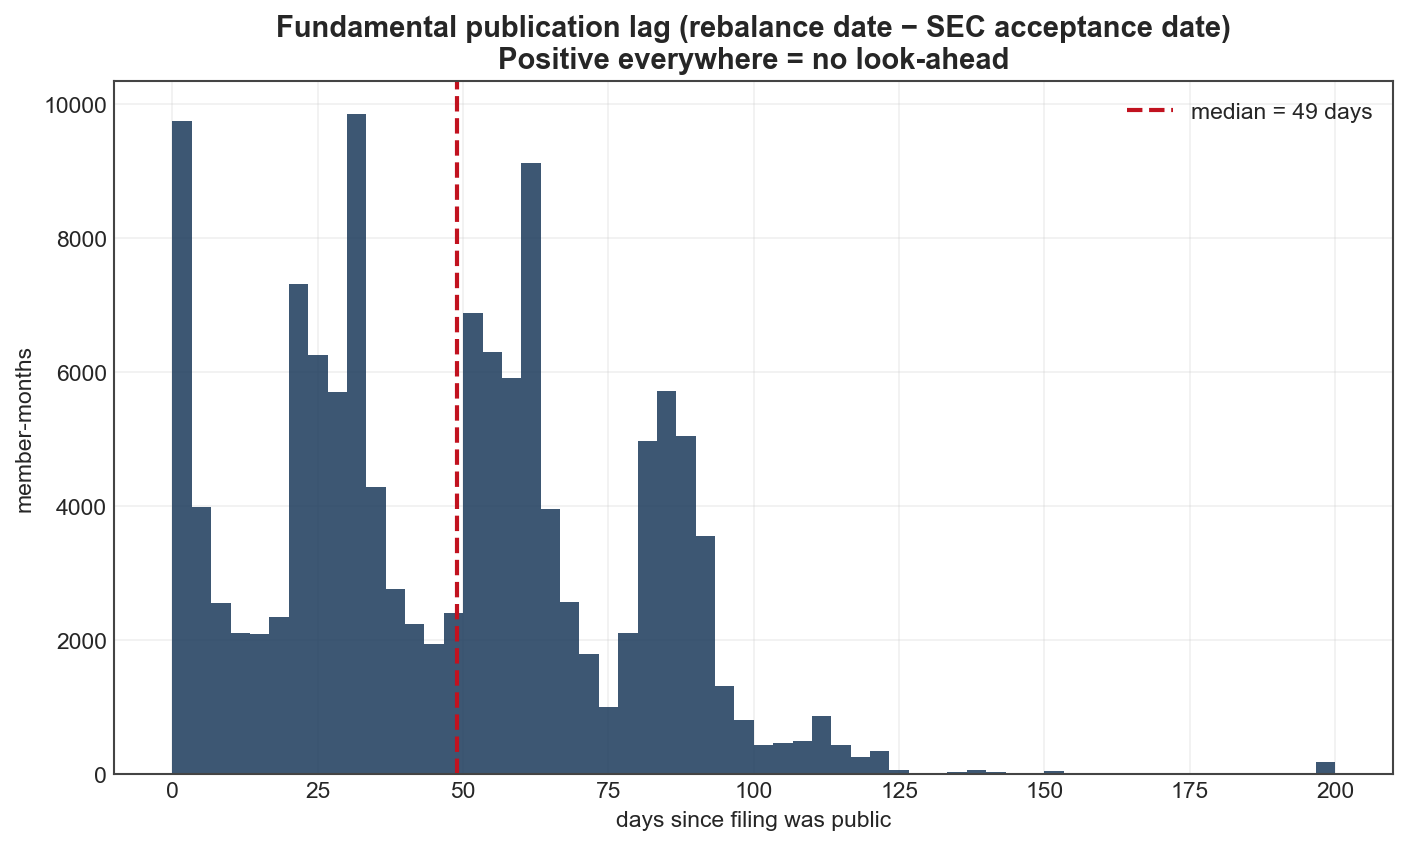

In [3]:
inv = clean[clean.investable]
print(f'investable member-months : {len(inv):,}')
print(f'look-ahead violations    : {int((inv.acceptedDate > inv.date).sum())}')
print(f'filing lag (days): median {inv.filing_lag_days.median():.0f} | p95 {inv.filing_lag_days.quantile(0.95):.0f}')
Image(filename=str(CHARTS / '01_filing_lag_hist.png'))

## 1.3 Coverage — and why the early cross-section is smaller
Membership is ~500 throughout, but the *investable* count (names with a usable FMP price +
fundamentals) starts near 260 in 2000 and rises to ~500. The reason is **price coverage**, not
membership: FMP's price API does not serve many tickers that later delisted/merged/renamed.

2000-06-30 funnel:
  index members          : 494
  missing FMP price       : 228
  have price, no fundas   : 3
  investable              : 263
  of missing-price names, NOT in todays index: 95%


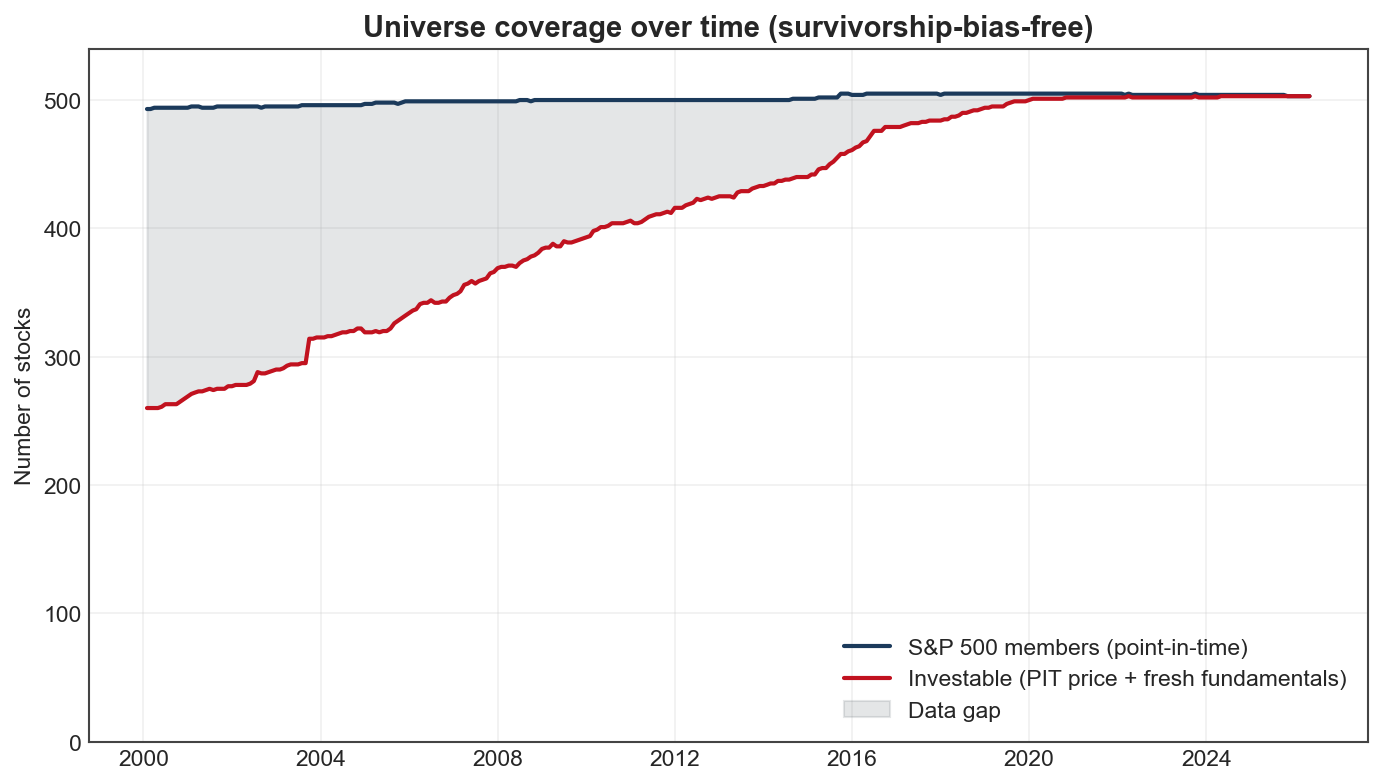

In [4]:
d = raw[raw.date == '2000-06-30']
print('2000-06-30 funnel:')
print(f'  index members          : {len(d)}')
print(f'  missing FMP price       : {int((~d.has_price).sum())}')
print(f'  have price, no fundas   : {int((d.has_price & ~d.has_fundamentals).sum())}')
print(f'  investable              : {int(d.investable.sum())}')
cur = set(members_now.symbol)
miss = d[~d.has_price]
print(f'  of missing-price names, NOT in todays index: {(~miss.symbol.isin(cur)).mean():.0%}')
Image(filename=str(CHARTS / '01_universe_coverage.png'))

**Reading it:** 94% of the missing-price names later left the index — they are the dead/renamed
tickers FMP no longer serves. So the *universe* is unbiased, but early-year *data availability*
tilts toward survivors. **Mitigation:** require a minimum cross-section per month for IC/model
evaluation and report a robustness window on the high-coverage period (~2008+) alongside the full
sample. The field-availability map:

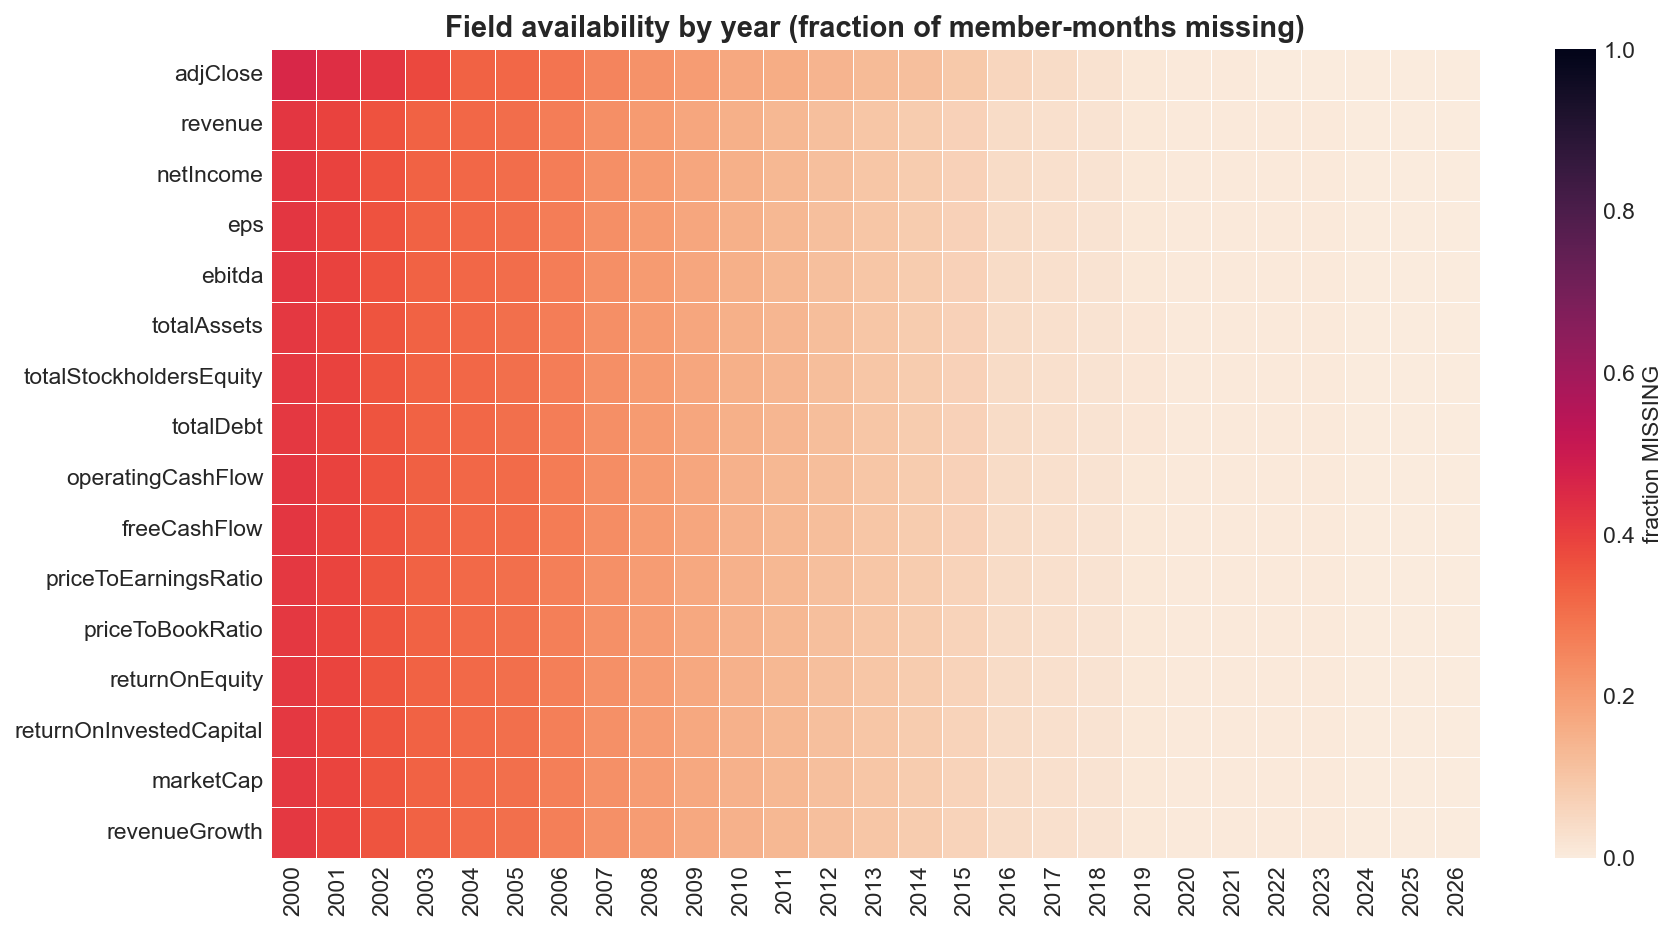

In [5]:
Image(filename=str(CHARTS / '01_missing_data_heatmap.png'))

# 1b. Independent Data Validation (FMP vs Yahoo Finance)

We cross-check the FMP prices against a second vendor (Yahoo). Adjusted *levels* aren't
comparable, so we compare **monthly returns**. Yahoo's fundamentals are too shallow for a
historical comparison, so the rigorous check is on prices/returns — where data bugs live.

symbols compared                 : 630
symbols with return corr >= 0.99 : 89.3%
median monthly |return diff|     : 0.0014


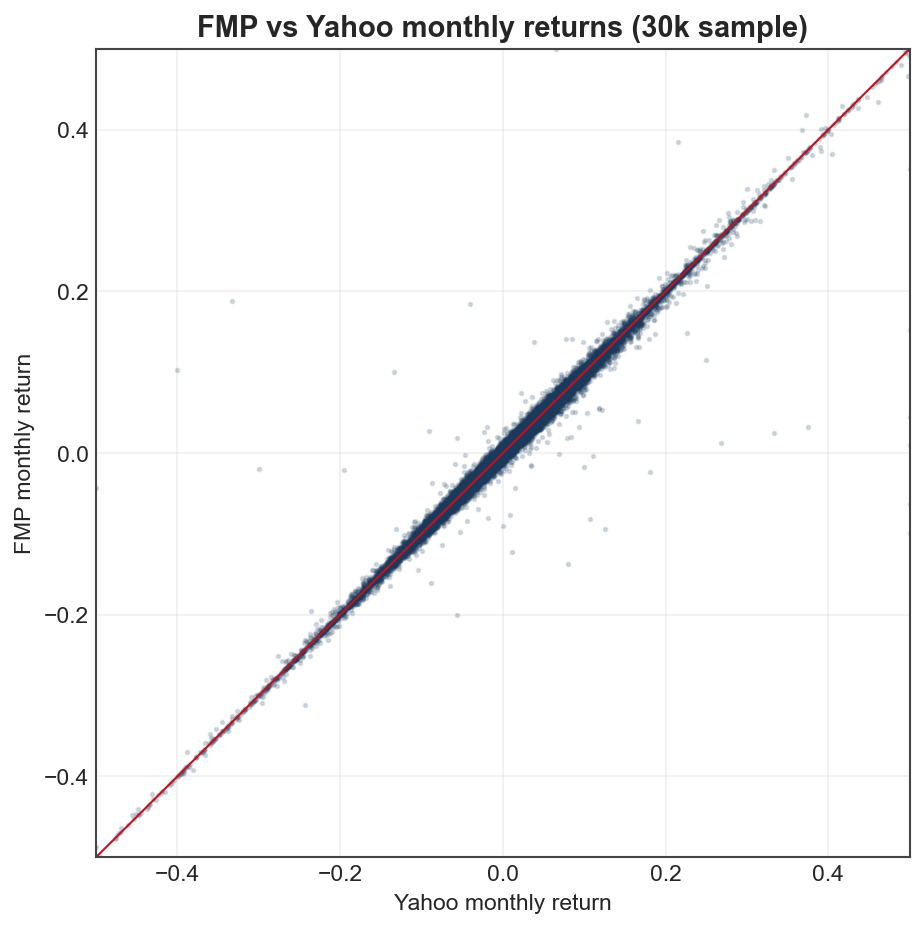

In [6]:
obs = pd.read_parquet(P / 'yahoo_validation_obs.parquet')
rep = pd.read_parquet(P / 'yahoo_validation_by_symbol.parquet')
print(f'symbols compared                 : {int(rep.ret_corr.notna().sum())}')
print(f'symbols with return corr >= 0.99 : {(rep.ret_corr >= 0.99).mean():.1%}')
print(f'median monthly |return diff|     : {obs.abs_ret_diff.median():.4f}')
Image(filename=str(CHARTS / '02_fmp_vs_yahoo_scatter.png'))

## 1b.1 Coverage & the big discrepancies
Yahoo drops delisted tickers, so it has no data for ~112 names FMP retains (another point for
FMP on survivorship). Only 41 symbols are flagged; they are corporate-action back-adjustment
(MO, HPQ), corrupted FMP series (CPWR), or ticker mismatches.

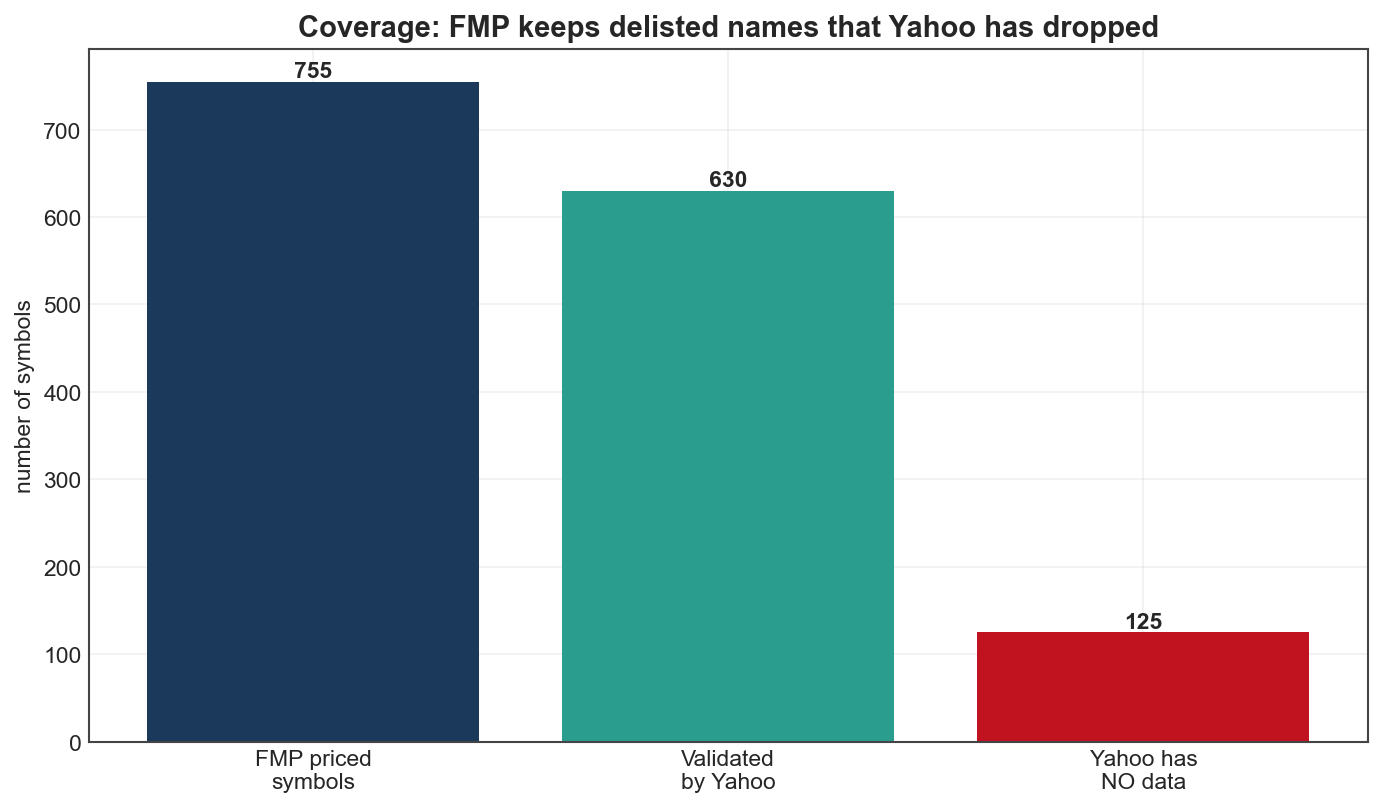

In [7]:
Image(filename=str(CHARTS / '02_coverage_comparison.png'))

In [8]:
cols = ['symbol','n_months','ret_corr','median_abs_ret_diff','max_abs_ret_diff']
rep.sort_values('max_abs_ret_diff', ascending=False).head(12)[cols].round(4)

,symbol,n_months,ret_corr,median_abs_ret_diff,max_abs_ret_diff
0,FMC,209,0.9138,0.0019,34.2969
1,FIS,233,-0.0953,0.0025,4.4545
2,CPWR,59,0.0147,0.3109,3.1242
3,WEN,103,0.3428,0.0013,2.2907
4,MO,315,0.4218,0.0115,2.0504
5,EXPE,222,0.6518,0.0003,1.6953
6,WY,315,0.5916,0.0063,1.6598
7,ROK,313,0.7100,0.0044,1.5995
8,MDLZ,229,0.2202,0.0050,1.3542
9,JCI,298,0.7808,0.0050,1.2515


## 1b.2 Conservative cleaning
`qfr.data.clean` excludes only genuinely corrupted series and nulls individual bad/spin-off
months (keeping those symbols), then recomputes forward returns -> `master_clean.parquet`.

In [9]:
print(f'symbols excluded (corrupted): {clean.loc[clean.excluded_corrupted, "symbol"].nunique()}')
print(f'months nulled (suspect)     : {int(clean.suspect_month.sum())}')
print(f'investable: {int(raw.investable.sum()):,} (raw) -> {int(clean.investable.sum()):,} (clean)')

symbols excluded (corrupted): 1
months nulled (suspect)     : 38
investable: 130,817 (raw) -> 130,737 (clean)


# 2. Exploratory Data Analysis

Now we look at the raw factor *inputs* on the clean panel before engineering anything — their
distributions, outliers, correlations and time dynamics. These findings justify the
winsorisation / standardisation / ranking choices in Part 3.

## 2.1 Data + validation gate

In [10]:
from qfr.eda import INPUTS
m = clean[clean.investable]
by_mo = m.groupby('date').size()
print(f'investable rows : {len(m):,}  over {m.date.nunique()} months')
print(f'names/month     : min {by_mo.min()}, median {int(by_mo.median())}, max {by_mo.max()}')
print(f'inputs analysed : {len(INPUTS)}')
print(f'input completeness (investable): {(1 - m[INPUTS].isna().mean()).min():.1%} .. 100%')

investable rows : 130,737  over 316 months
names/month     : min 260, median 425, max 503
inputs analysed : 19
input completeness (investable): 100.0% .. 100%


## 2.2 Distributions & shape
The raw fundamental ratios are **extraordinarily fat-tailed** — skewness in the hundreds, excess
kurtosis in the tens of thousands (a near-zero denominator, e.g. tiny book value, produces giant
P/B or ROE). This is the central EDA fact driving every later transform.

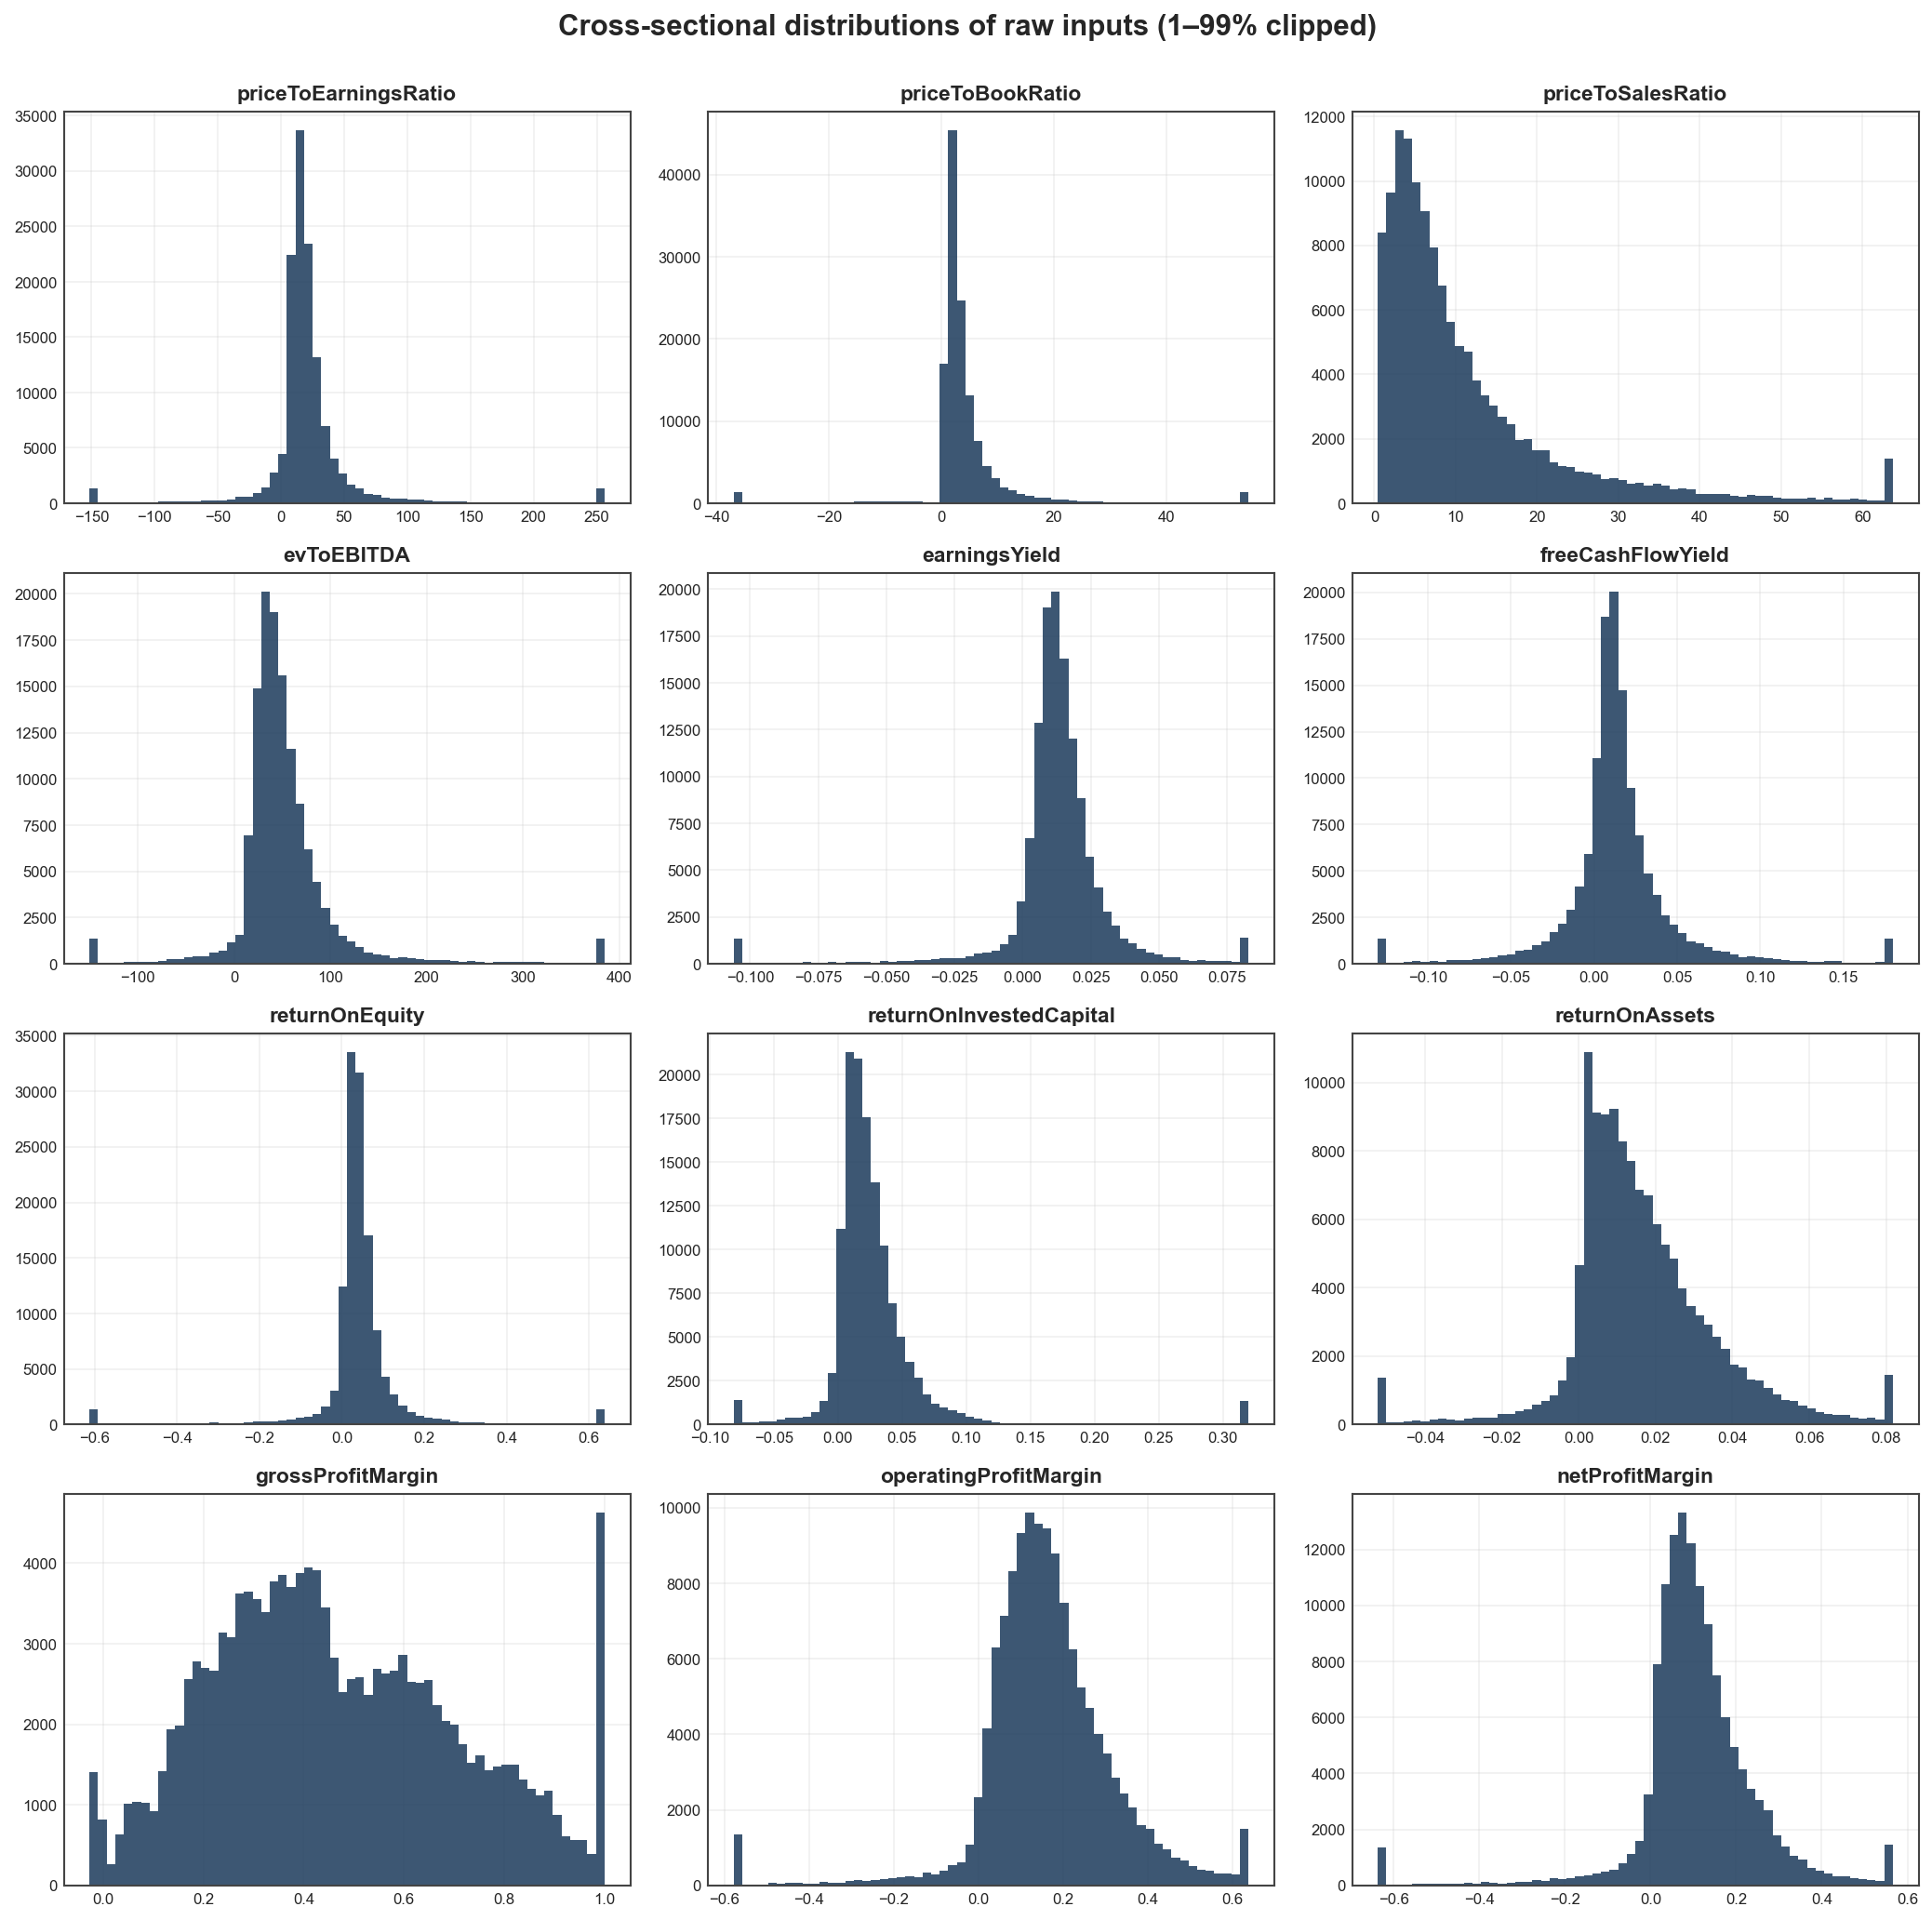

In [11]:
Image(filename=str(CHARTS / 'eda_distributions.png'))

In [12]:
pd.read_csv(CHARTS / 'eda_summary_stats.csv', index_col=0)

,missing_%,median,skew,excess_kurtosis
field,,,,
priceToEarningsRatio,0.0,1.714560e+01,-35.02,8019.1
priceToBookRatio,0.0,2.672200e+00,208.73,43569.1
priceToSalesRatio,0.0,7.458300e+00,113.24,13720.8
evToEBITDA,0.0,4.419000e+01,204.18,42227.6
earningsYield,0.0,1.270000e-02,128.53,16574.2
freeCashFlowYield,0.0,1.190000e-02,155.41,24599.5
returnOnEquity,0.0,3.780000e-02,208.74,43572.8
returnOnInvestedCapital,0.0,2.030000e-02,207.97,43352.4
returnOnAssets,0.0,1.370000e-02,207.42,43190.8


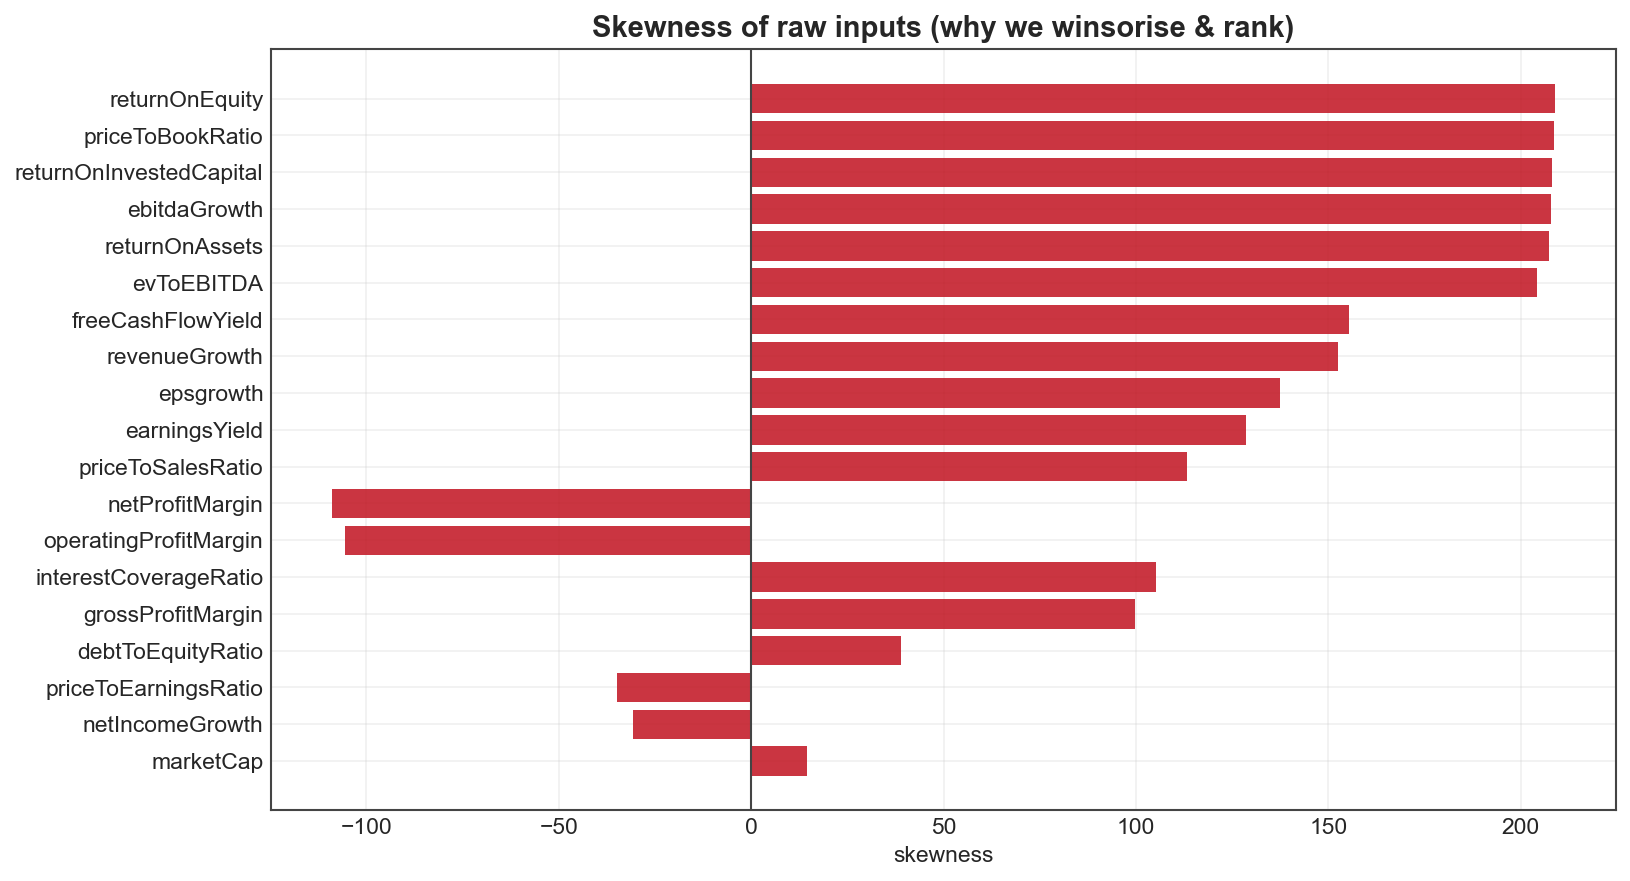

In [13]:
Image(filename=str(CHARTS / 'eda_skewness.png'))

## 2.3 Outliers
Cross-sectional z-scores show mass well beyond ±3σ for the ratio factors — raw z-scoring alone
would let a handful of names dominate. Hence winsorisation and, ultimately, rank-based features.

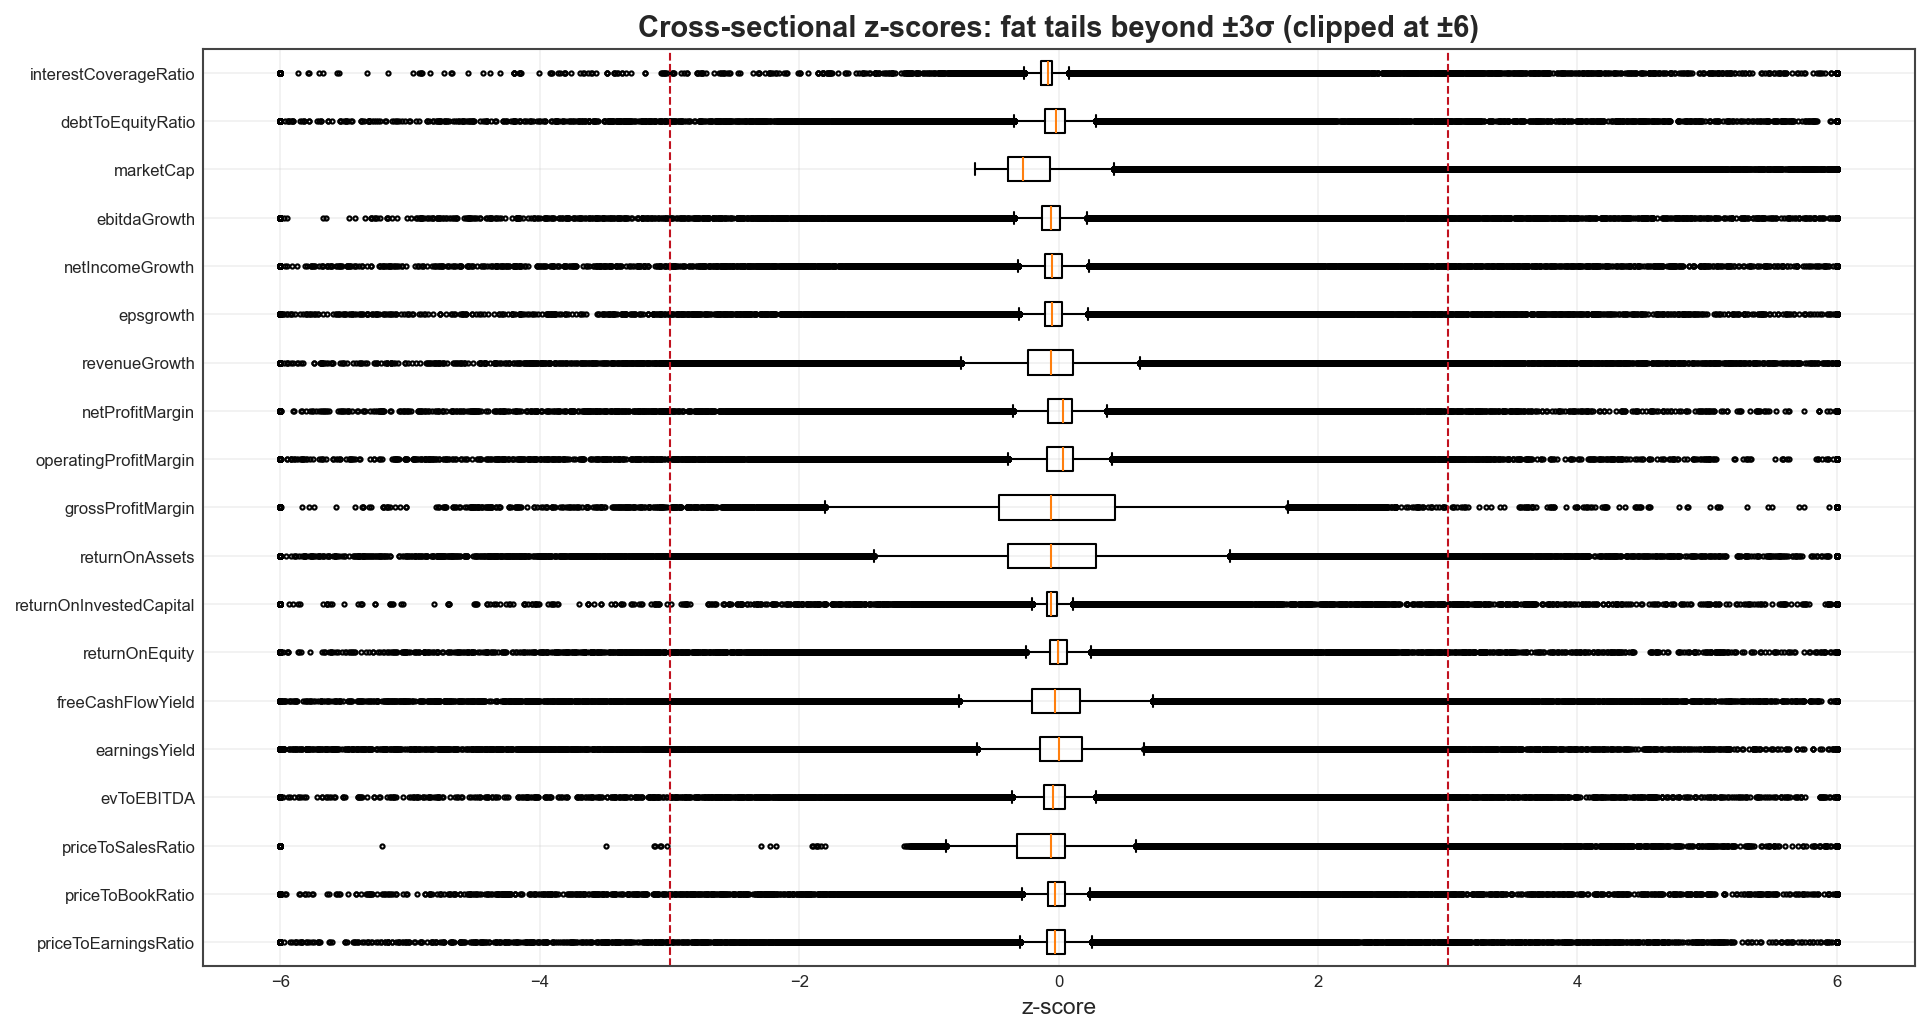

In [14]:
Image(filename=str(CHARTS / 'eda_outliers_box.png'))

## 2.4 Taming the tails: raw → winsorised z → rank
Winsorising + z-scoring centres a factor but leaves peaks; the **cross-sectional rank** is
uniform and outlier-immune — which is exactly why the ML stage learns to *rank*.

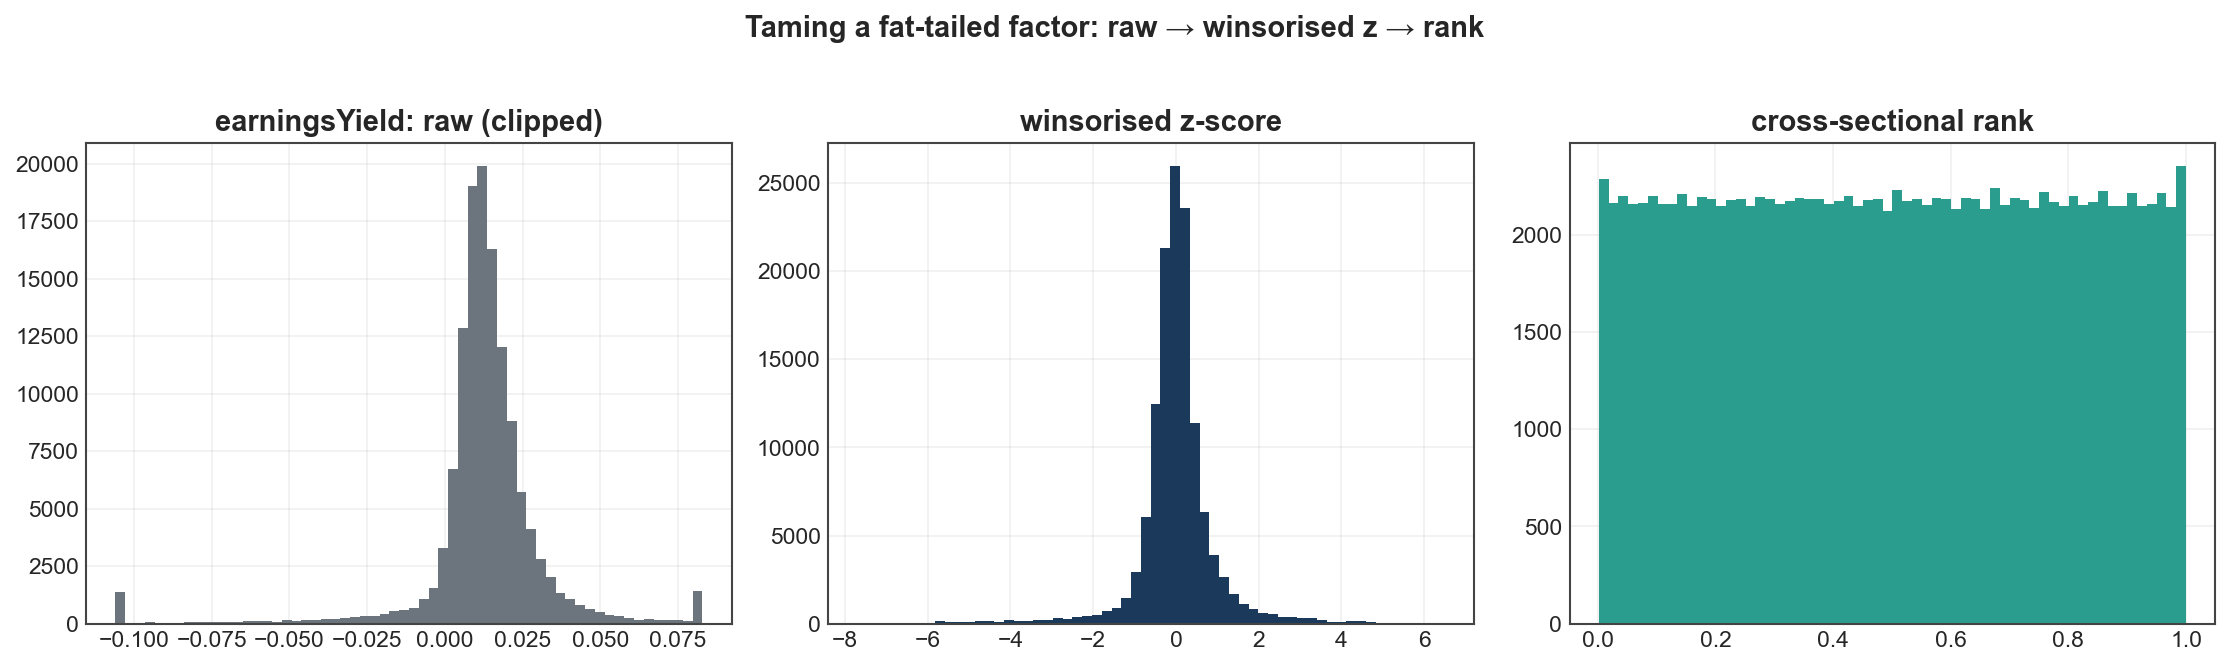

In [15]:
Image(filename=str(CHARTS / 'eda_transformation.png'))

## 2.5 Correlation & redundancy
Spearman correlation + clustering of the inputs: profitability/returns cluster, margins cluster,
valuation ratios cluster, growth clusters. This guides factor grouping and orthogonalisation.

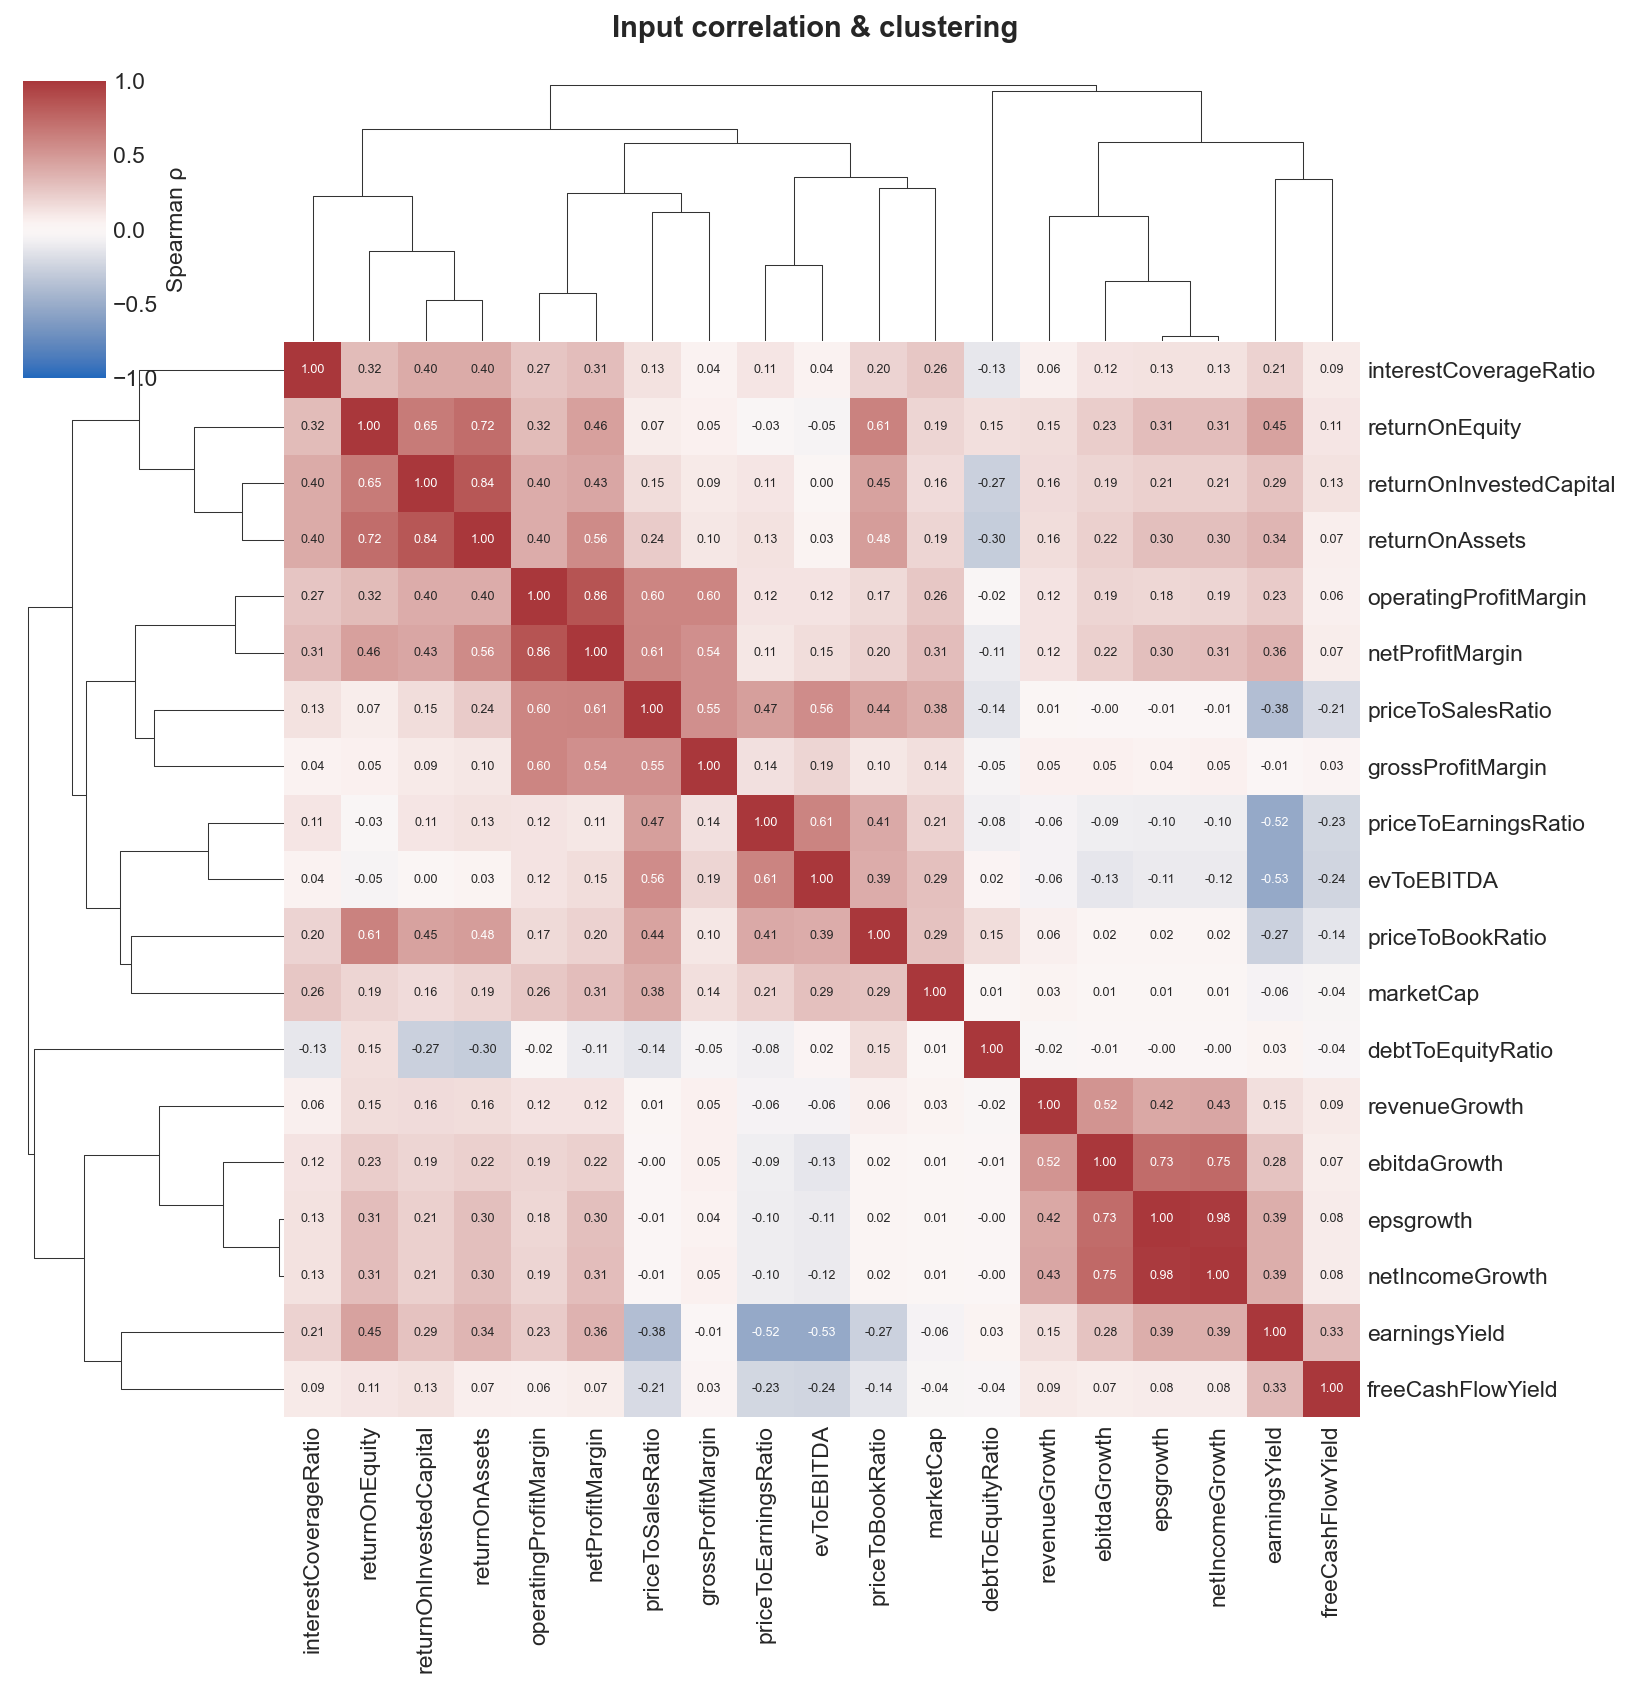

In [16]:
Image(filename=str(CHARTS / 'eda_correlation_cluster.png'))

## 2.6 Time dynamics
Sector mix of the investable universe over time, and the cross-sectional dispersion of forward
returns — the latter is the *opportunity set*: wider dispersion means more for a ranking model
to capture (note the spikes around 2000–02, 2008–09 and 2020).

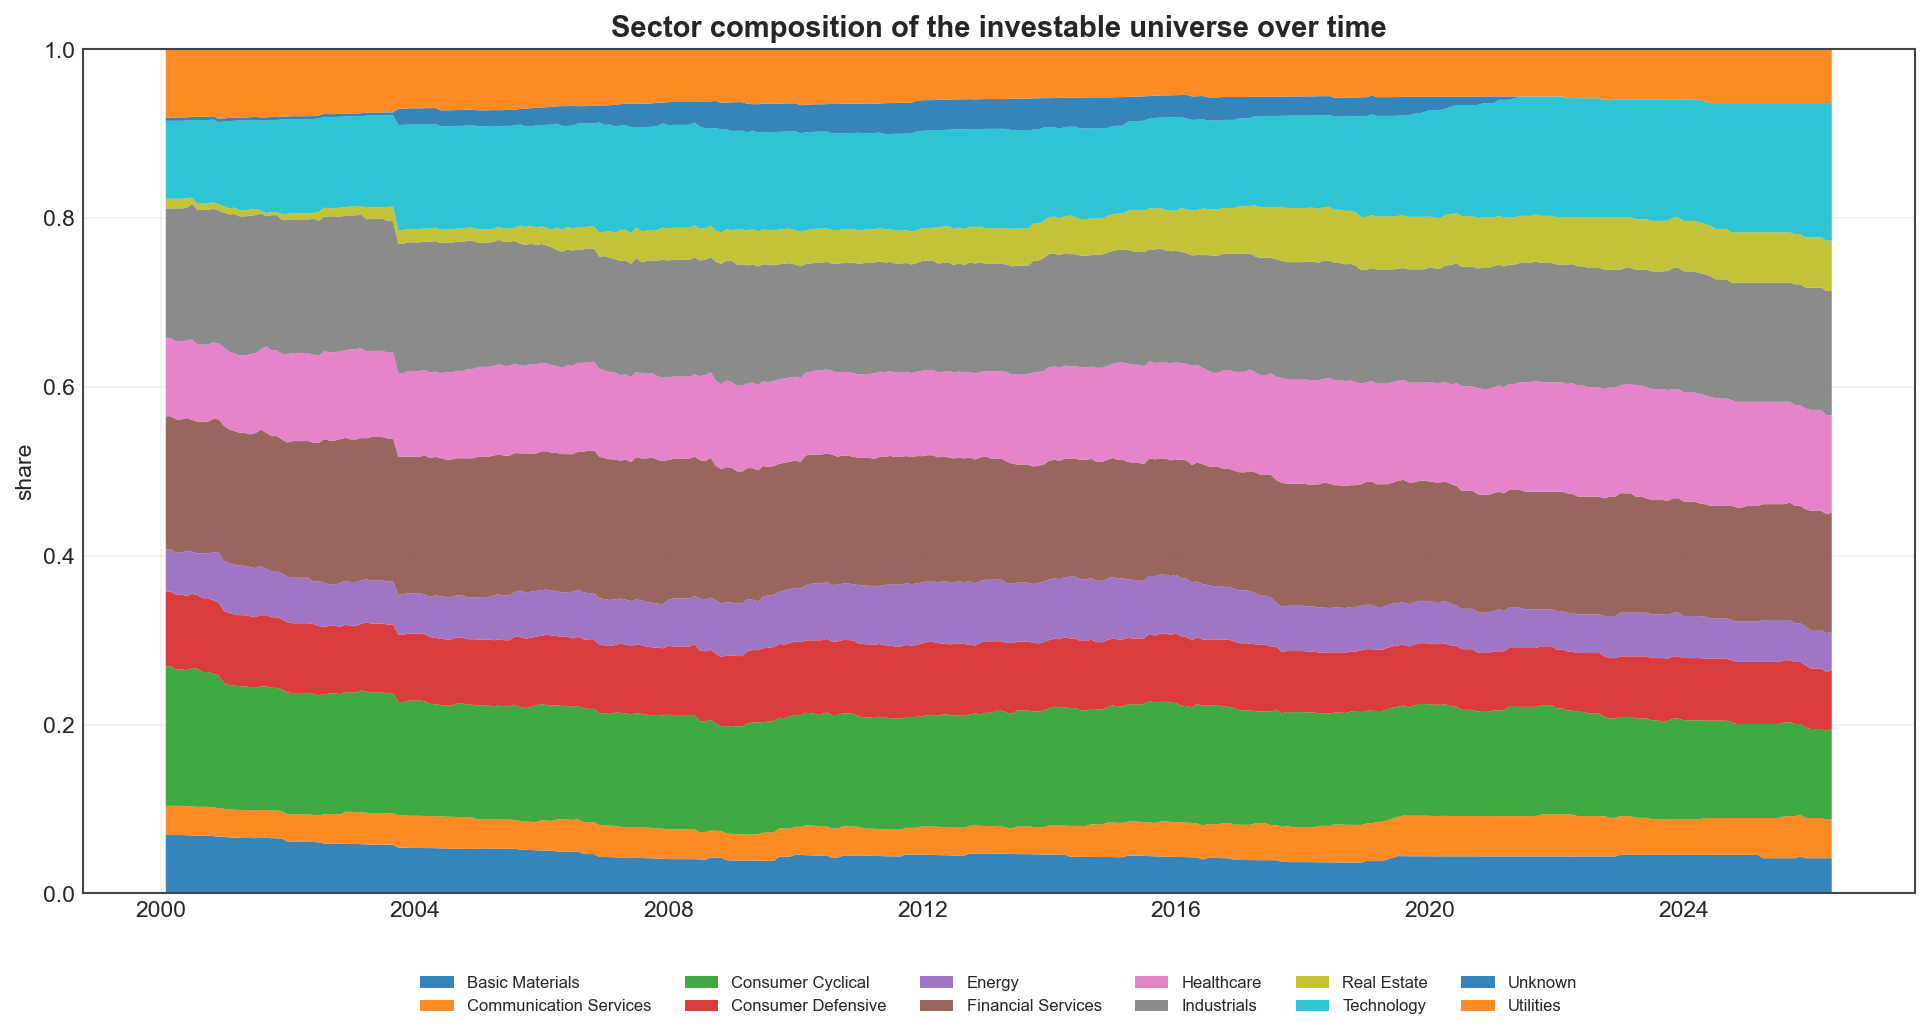

In [17]:
Image(filename=str(CHARTS / 'eda_sector_over_time.png'))

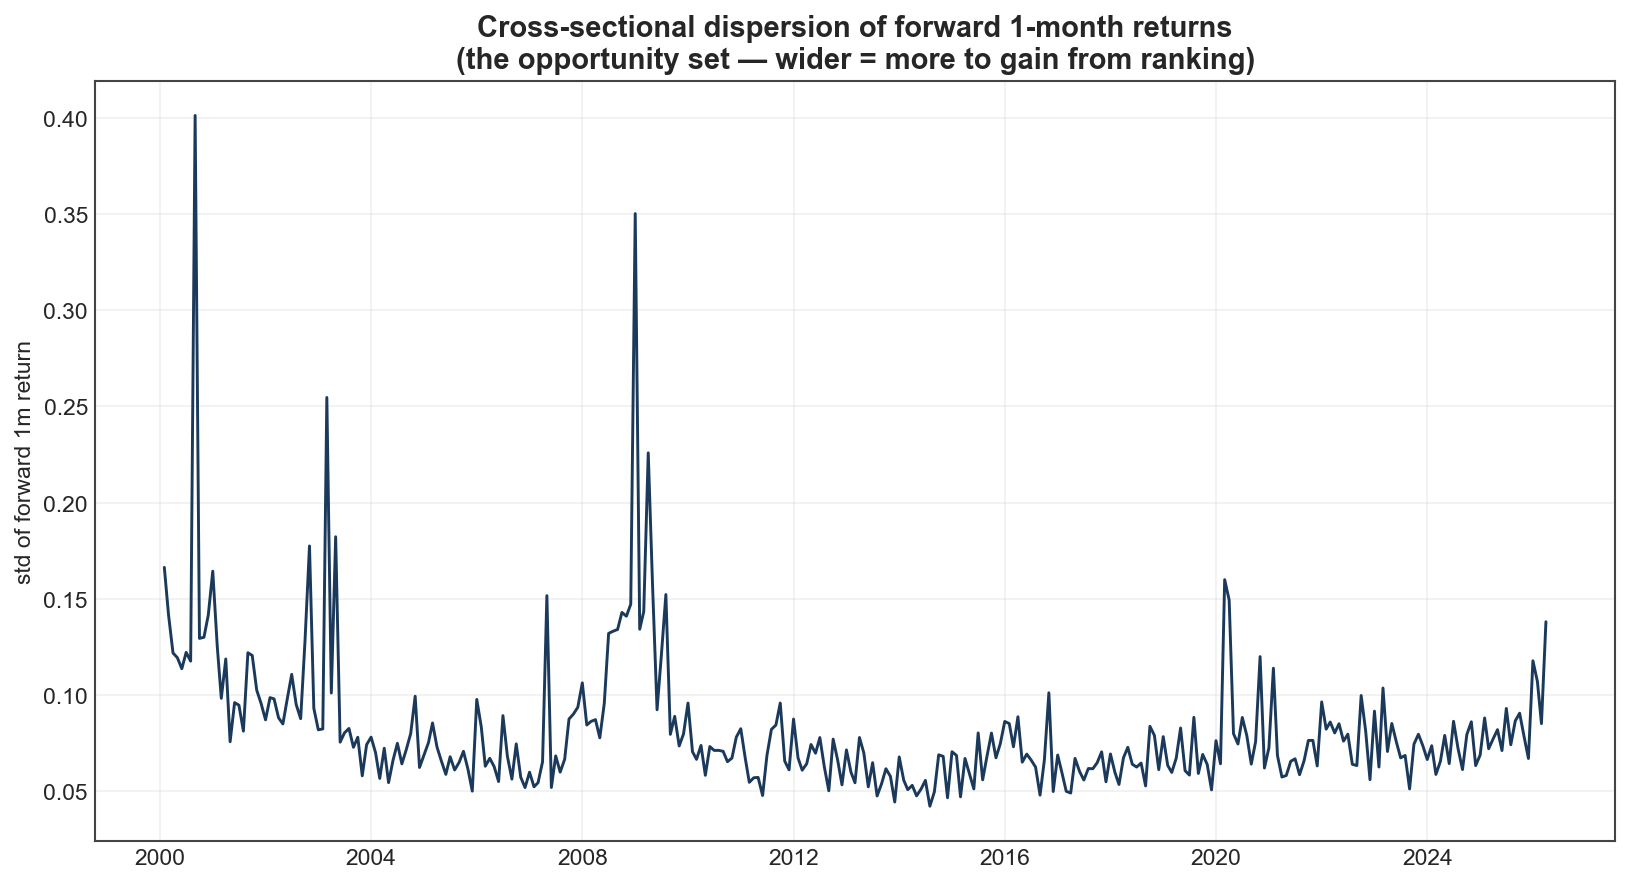

In [18]:
Image(filename=str(CHARTS / 'eda_return_dispersion.png'))

## Takeaways → Part 3 (Factor Construction)
- Inputs are extremely fat-tailed → **winsorise (1/99%) then rank/z-score cross-sectionally**.
- Clear redundancy clusters → build *composite* Value/Quality/Momentum/Growth/Risk factors and
  watch collinearity.
- Return dispersion is time-varying → expect factor efficacy to vary by regime.
- Early-year coverage is thin/survivor-tilted → enforce a minimum cross-section and report a
  high-coverage robustness window.

**Next:** construct the factor library (`qfr.factors`) and validate it with information-coefficient
analysis.